Note: Most of the code snippets and notes are based on "Introduction to Deep Learning with Pytorch" course on DataCamp. Also some content are AI generated.

# Part 1: Introduction to Pytorch, a deep learning library



PyTorch is an open-source deep learning framework developed by Facebook's AI Research lab (FAIR). It is widely used for building and training neural networks due to its flexibility, ease of use, and strong support for dynamic computation graphs.

### 🔧 Key Features:
Dynamic Computational Graphs (Define-by-Run): You can change the graph on the fly, making debugging and experimentation easier.

Tensor Computation: Similar to NumPy, but with GPU acceleration.

Autograd: Automatic differentiation for gradient calculation.

Modules & Layers: torch.nn provides prebuilt layers and loss functions.

GPU Support: Seamless execution on CPU or CUDA GPUs.

Interoperability: Integrates well with NumPy, ONNX, and other tools.

### ✅ Use Cases:
Image classification (e.g., CNNs)

Natural language processing (e.g., Transformers)

Reinforcement learning

Generative models (e.g., GANs, VAEs)

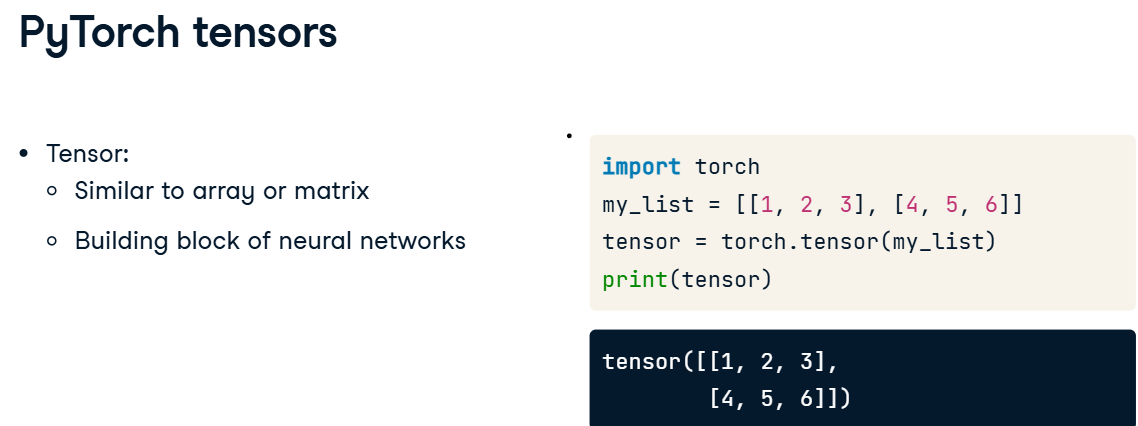

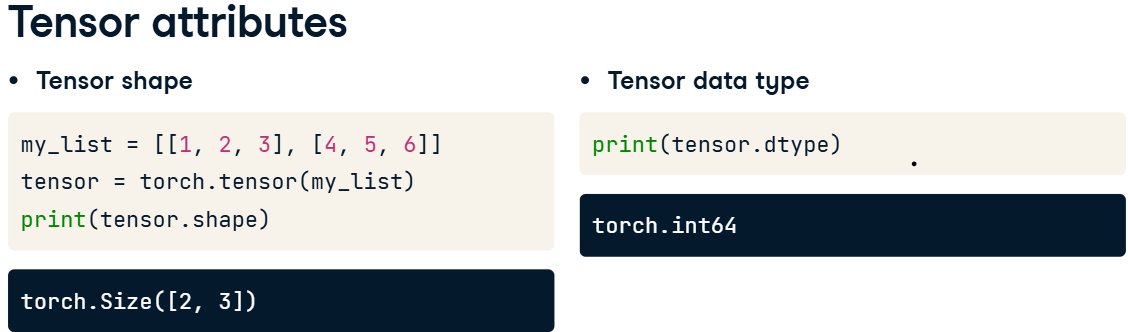

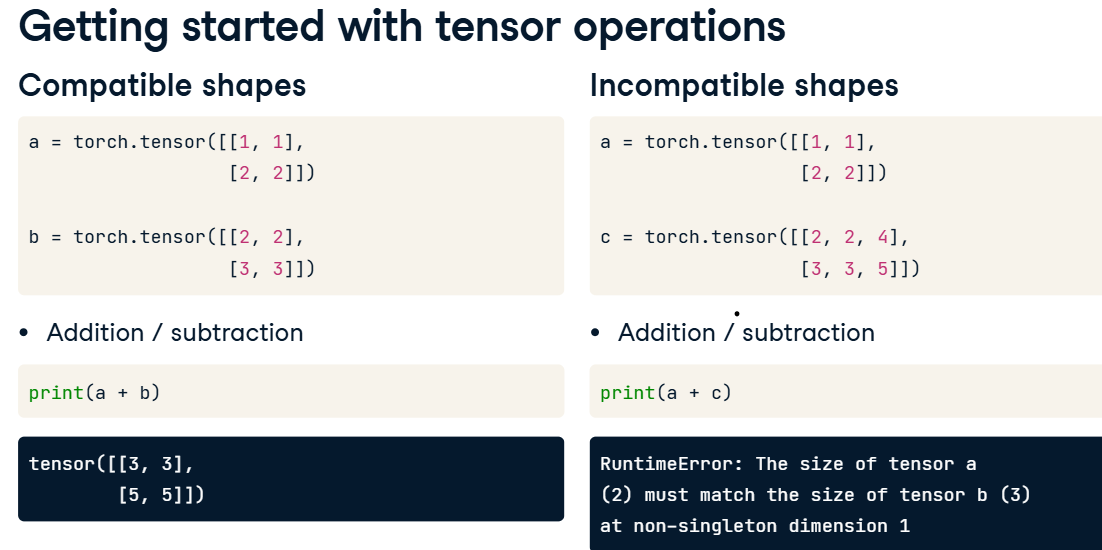

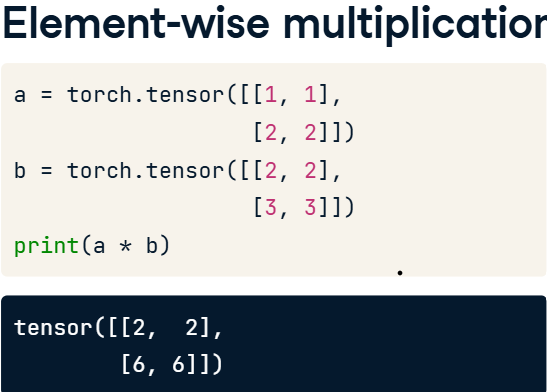

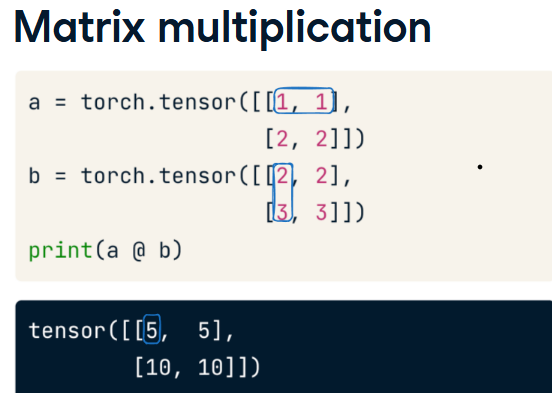

## Neural Networks and layers

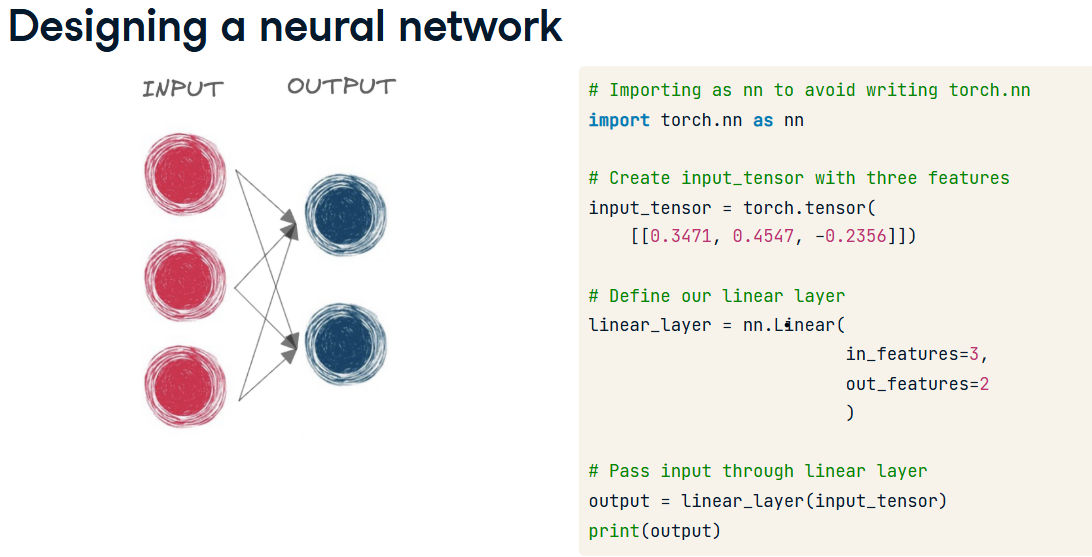

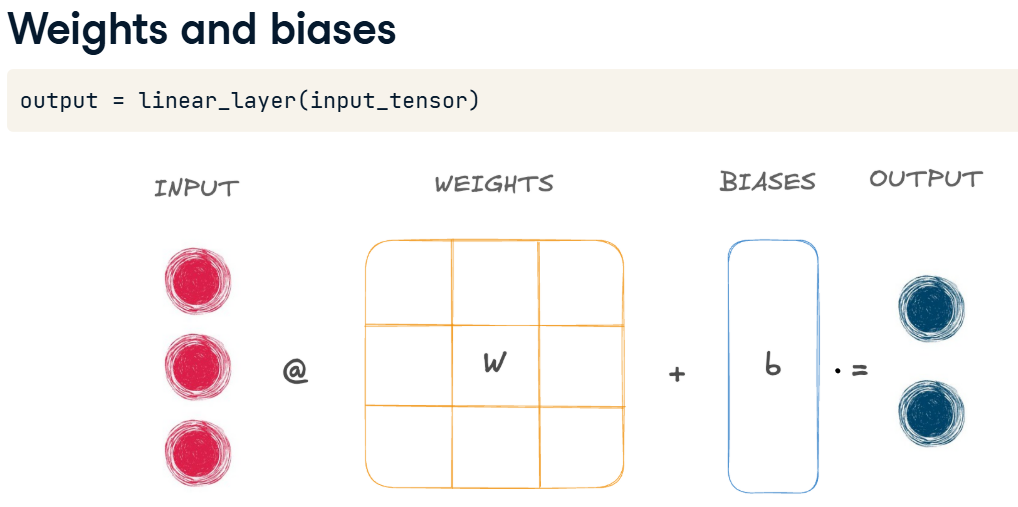

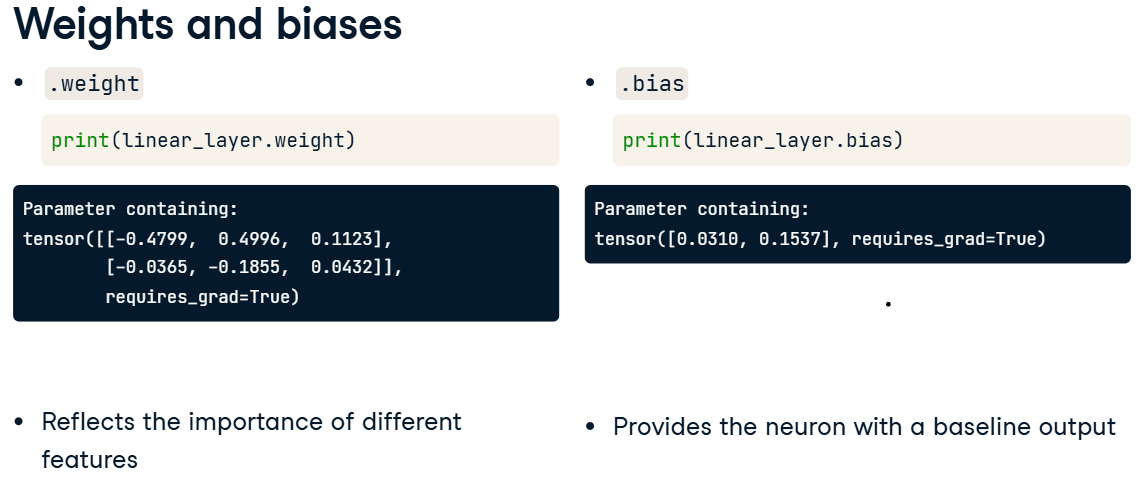


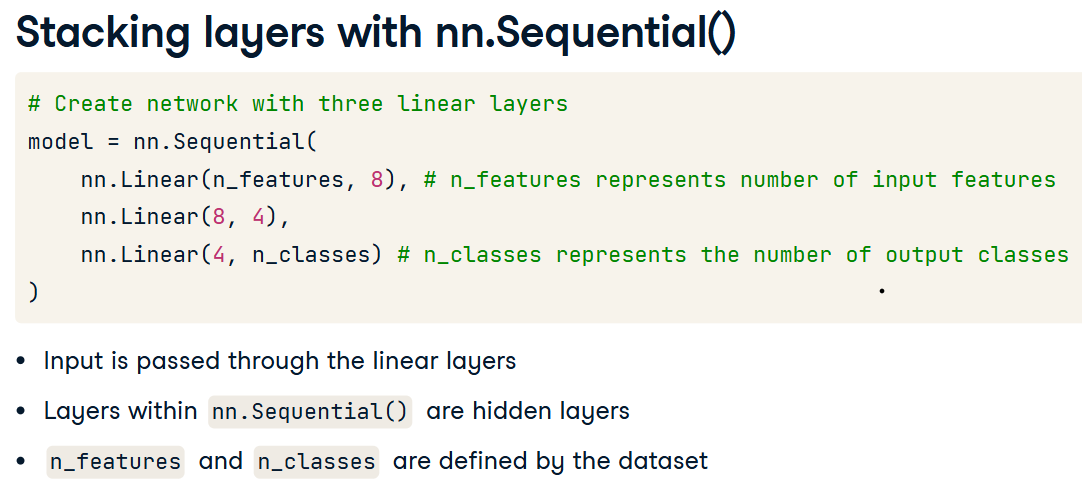

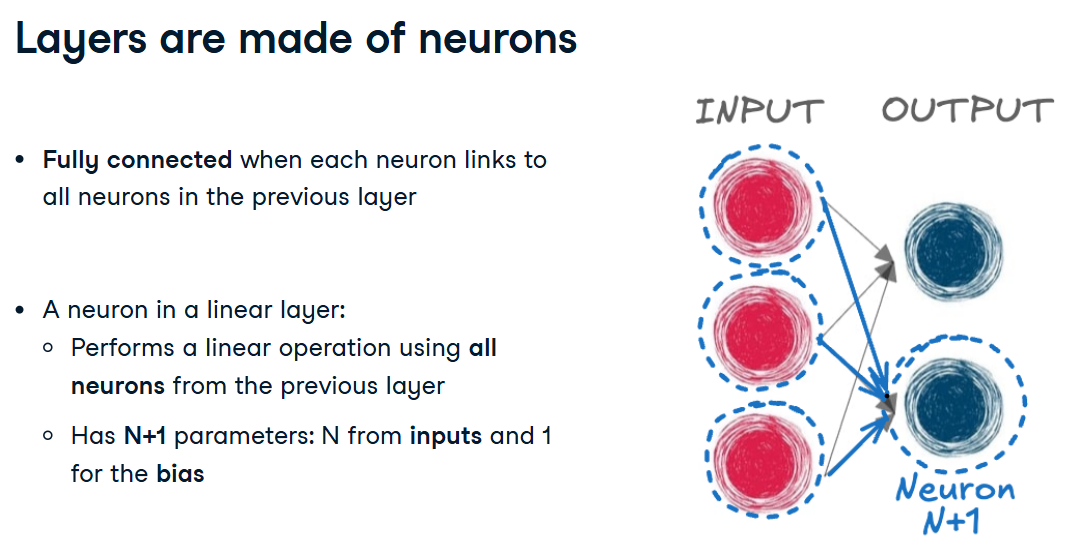

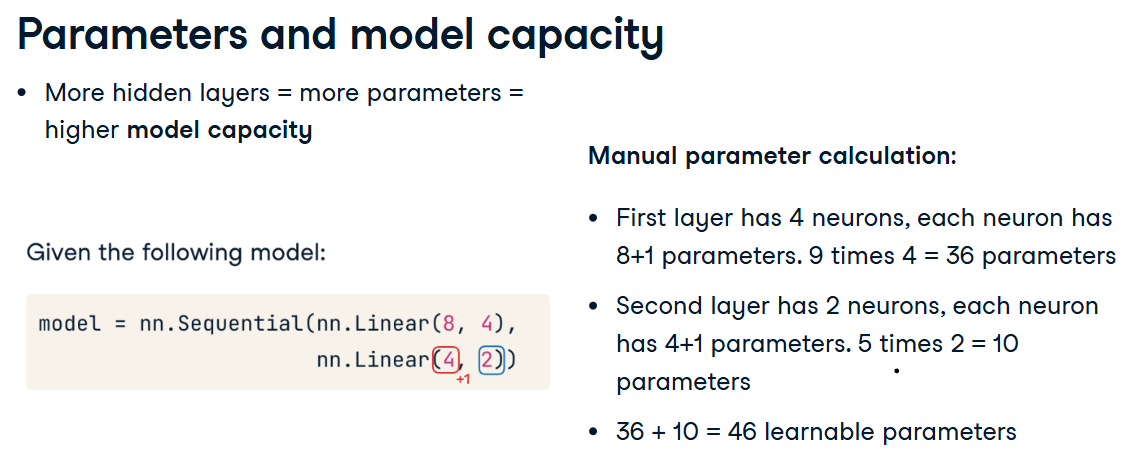

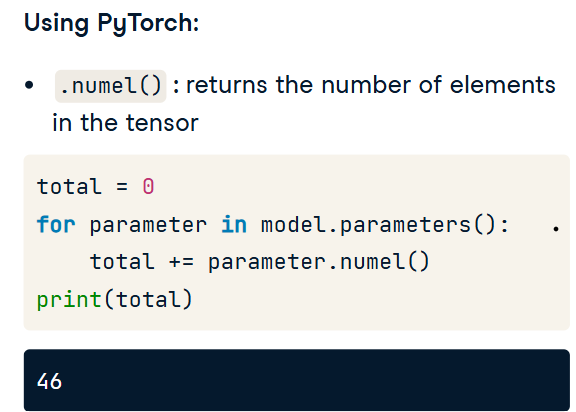

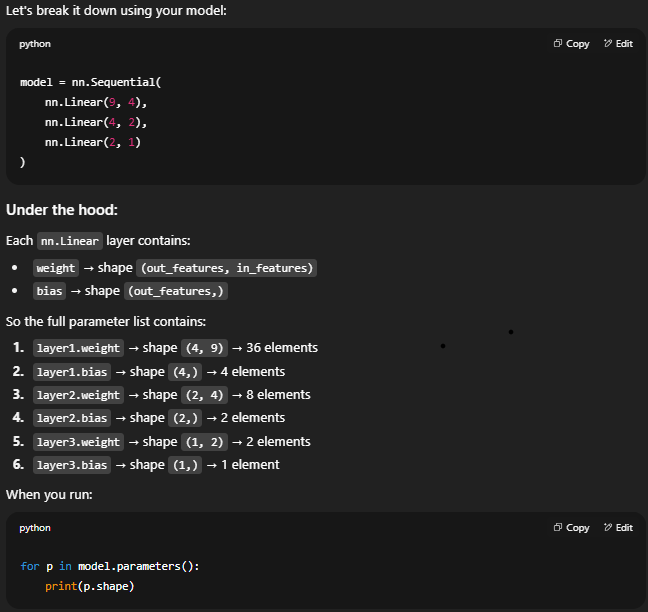
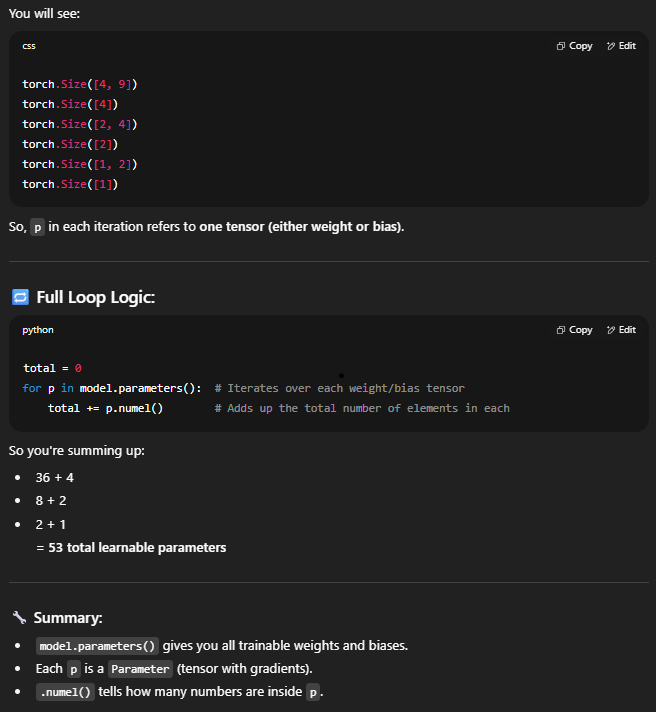

## torch.nn
The torch.nn module in PyTorch is a core sub-library that provides all the building blocks for designing and training neural networks.

### 🔹 What is torch.nn used for?
It contains:

### 1. Predefined Layers
You can easily create neural networks using built-in layers like:

nn.Linear – Fully connected (dense) layer

nn.Conv2d – Convolutional layer for images

nn.LSTM – Recurrent layer

nn.BatchNorm2d – Batch normalization

nn.Dropout – Dropout for regularization

### 2. Activation Functions
Includes most commonly used activation functions:

nn.ReLU()

nn.Sigmoid()

nn.Tanh()

nn.LeakyReLU()

etc.

You can also use functional versions via torch.nn.functional.

### 3. Loss Functions
Provides loss functions used to train models:

nn.CrossEntropyLoss – for multi-class classification

nn.MSELoss – for regression

nn.BCELoss – for binary classification

etc.

### 4. Containers & Wrappers
Useful for combining layers and organizing models:

nn.Sequential – stack layers in order

nn.ModuleList, nn.ModuleDict – hold submodules

nn.Module – base class for all models

# Part 2: Neural Network architecture and hyperparameters


## Activation functions
Activation functions in deep learning introduce non-linearity into neural networks, allowing them to learn complex patterns. Without activation functions, a neural network would simply behave like a linear model regardless of its depth.

Here’s a summary of common activation functions, their formulas, pros, and cons:

🔹 1. Sigmoid (Logistic)  
Formula:

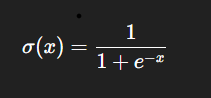

Pros:

Smooth gradient.

Output between 0 and 1 — useful for probabilities.

Cons:

Vanishing gradient problem.

Not zero-centered.

🔹 2. Tanh (Hyperbolic Tangent)  
Formula:

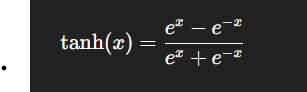
 
Pros:

Zero-centered output.

Stronger gradients than sigmoid.

Cons:

Still suffers from vanishing gradient.

🔹 3. ReLU (Rectified Linear Unit)  
Formula:

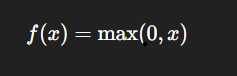

Pros:

Simple and fast.

Reduces vanishing gradient problem.

Sparse activation (many outputs are 0).

Cons:

Can cause neurons to "die" (output stuck at 0).

🔹 4. Leaky ReLU  
Formula:

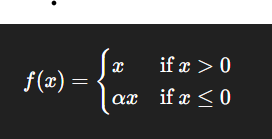
 
Pros:

Avoids dying ReLU problem.

Allows small gradient when inactive.

Cons:

Slightly more complex.

May still not be zero-centered.

🔹 5. Parametric ReLU (PReLU)  
Like Leaky ReLU, but α is learned during training.

Pros:

Adapts to data.

Solves dying ReLU problem more flexibly.

Cons:

Extra parameters can lead to overfitting.

🔹 6. ELU (Exponential Linear Unit)  
Formula:

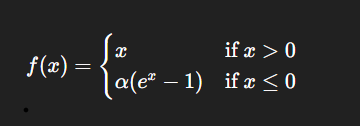
 
Pros:

Negative outputs push mean closer to 0.

Reduces bias shifts.

Cons:

Computationally more expensive than ReLU.

🔹 7. Softmax  
Used in output layer for multi-class classification

Formula:

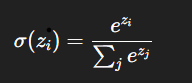
 
Pros:

Converts logits to class probabilities.

Sum of outputs = 1.

Cons:

Not suitable for hidden layers.



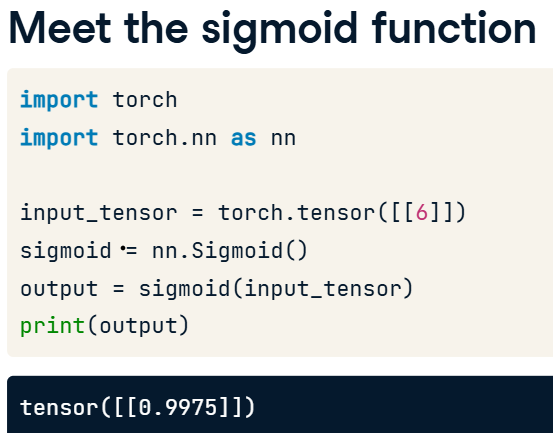

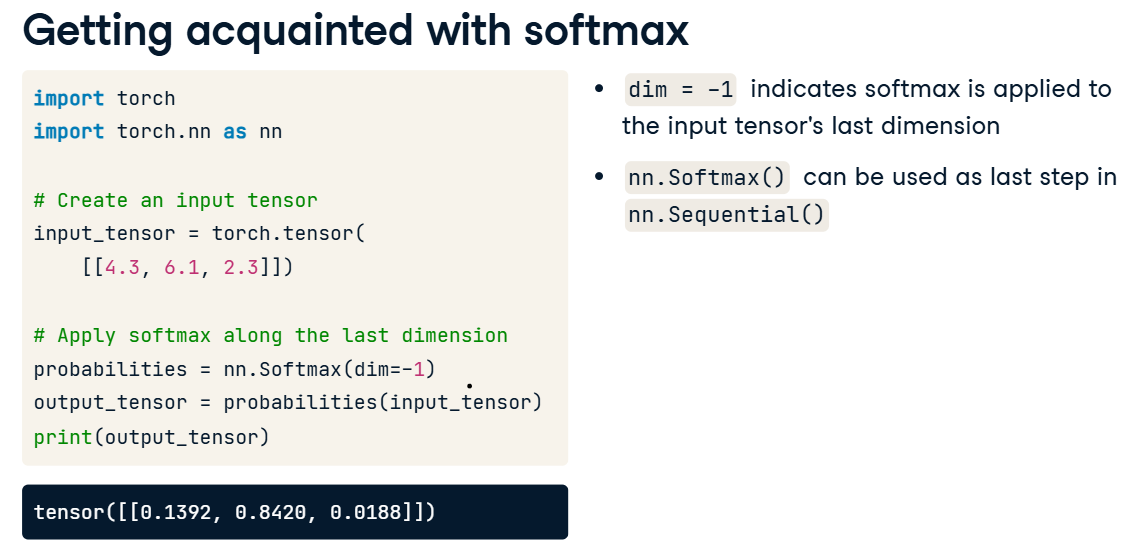

### 🔹 When to use nn.Softmax(dim=-1)
Use it when:

You're in the output layer of a classification model

You want to convert logits to probabilities

You're not using nn.CrossEntropyLoss (which applies Softmax internally)

## Forward pass
When input data flows through a neural network in the forward direction to produce outputs or predictions, it passes through each network layer. Calculations transform the data into new representations at every layer, which are passed to the next layer until the final output is produced. The purpose of the forward pass is to pass input data through the network and produce predictions or outputs based on the model's learned parameters, also known as weights and biases. This process is essential for both training and making new predictions.

The final output can be binary classifications, multi-class classifications, or numerical predictions (regressions). 

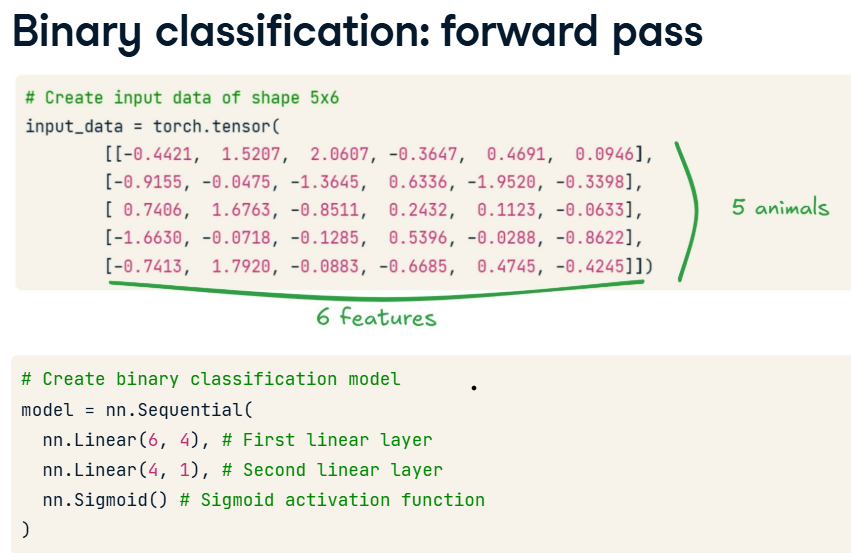

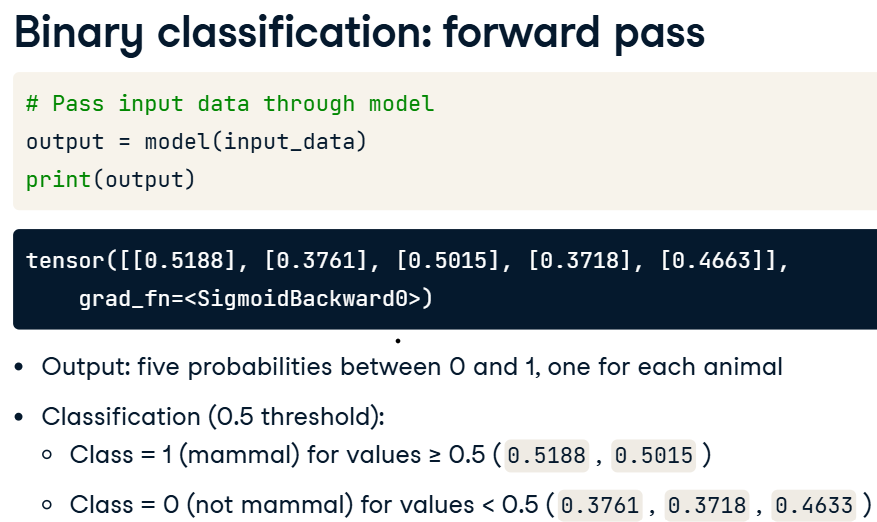

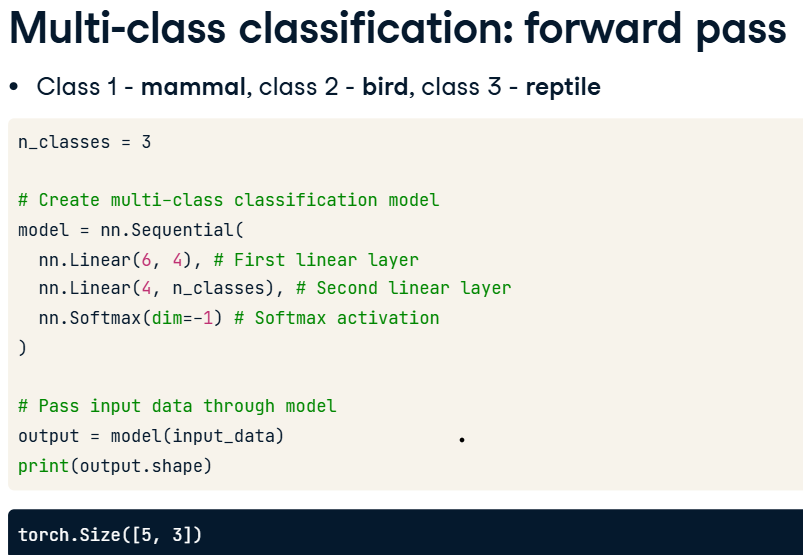

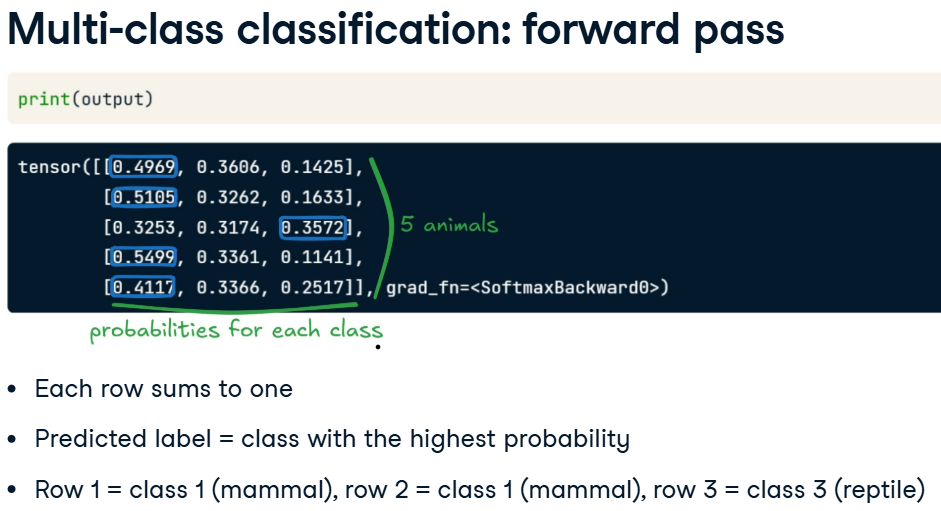



## Loss function
A loss function measures how well your model's predictions match the actual target labels. During training, the goal is to minimize this loss using optimization (e.g. gradient descent).

The loss function, another component of neural networks, tells us how good our model is at making predictions during training. It takes a model prediction, y-hat, and true label, or ground truth, y, as inputs, and outputs a float.

### One-hot encoding concepts
Loss is calculated using a loss function, F, which takes the ground truth y and the prediction yhat as inputs and outputs a numerical loss value. In our animal example, possible values for our true class of y are integers 0, 1 or 2. yhat is the raw prediction before applying the softmax function. It is a tensor with the same dimensions as the number of classes N. If N is three, the softmax output is a tensor of shape 1 by 3.

We use one-hot encoding to convert an integer y into a tensor of zeros and ones so we can compare to evaluate model performance. For example, if y = 0 with three classes, the encoded form is 1, 0, 0.

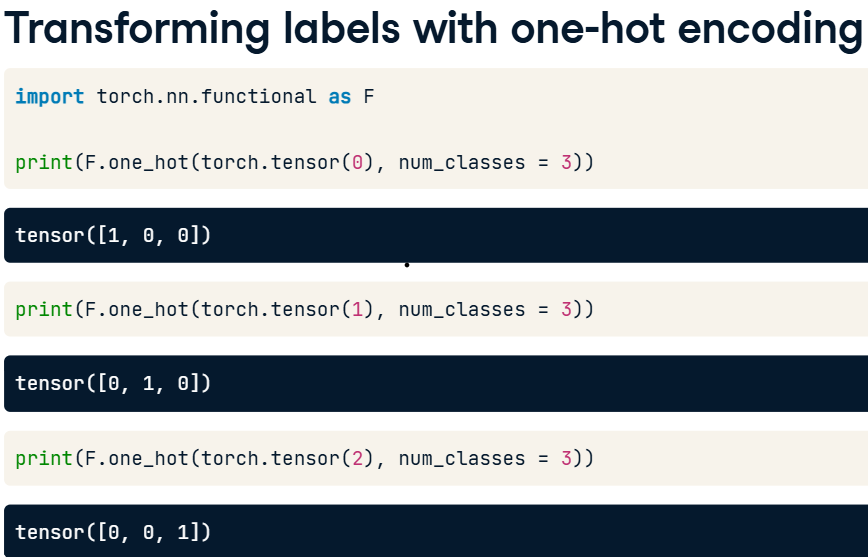

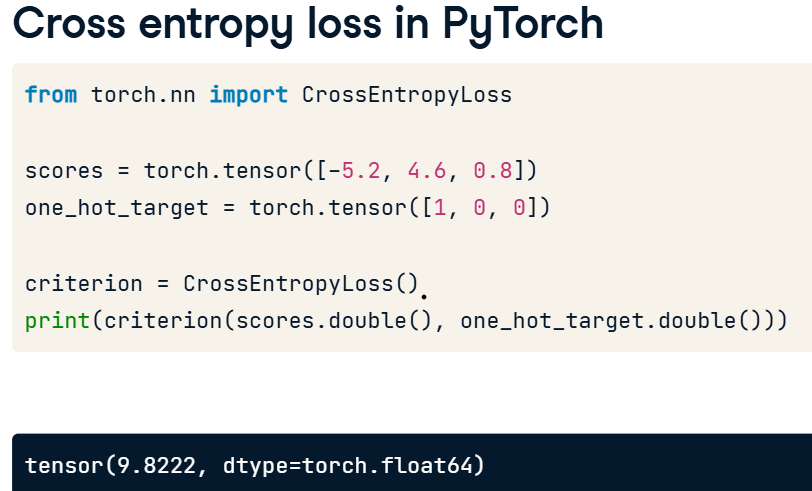

## Using derivatives to update model parameters
### What is Backpropagation?
Backpropagation is the core algorithm used to train deep neural networks. It allows the network to learn by adjusting its weights based on the error it makes when predicting.

The goal of training is to minimize the loss (difference between predicted output and true output).

Backpropagation efficiently computes how the loss changes with respect to each weight in the network.

This is done by propagating the error backward through the network, layer by layer.

### Role of Derivatives in Backpropagation
The key mathematical tool in backpropagation is the derivative (or gradient). Derivatives tell us how sensitive a function is to its input.

In deep learning, the function is the neural network’s output with respect to its parameters (weights).

The derivative of the loss with respect to each weight tells us how much changing that weight will change the loss.

We use these derivatives to update the weights and reduce the loss.

### Step-by-Step of Backpropagation Using Derivatives
Forward Pass:

Input data goes through the network to produce predictions.

Calculate the loss comparing prediction to true output.

Compute Loss Derivative:

Calculate derivative of loss with respect to the output of the network.

Backward Pass:

Using the chain rule of calculus, compute derivatives of the loss with respect to weights layer by layer.

For each layer:

Compute gradients of loss w.r.t weights and biases.

Propagate gradient backward to previous layers.

Update Weights:

Use the gradients to adjust the weights (e.g., via gradient descent):

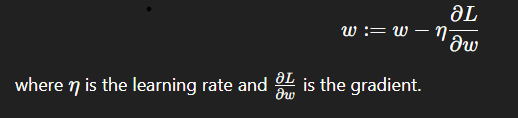

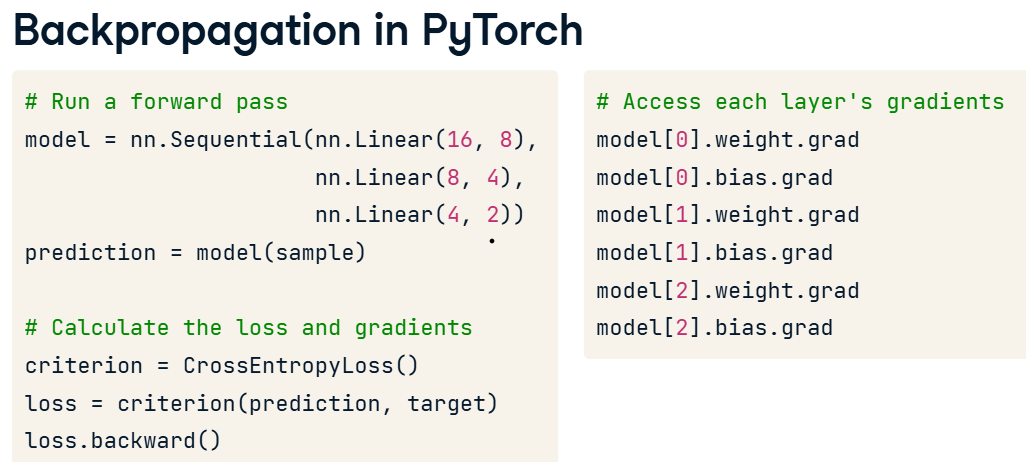

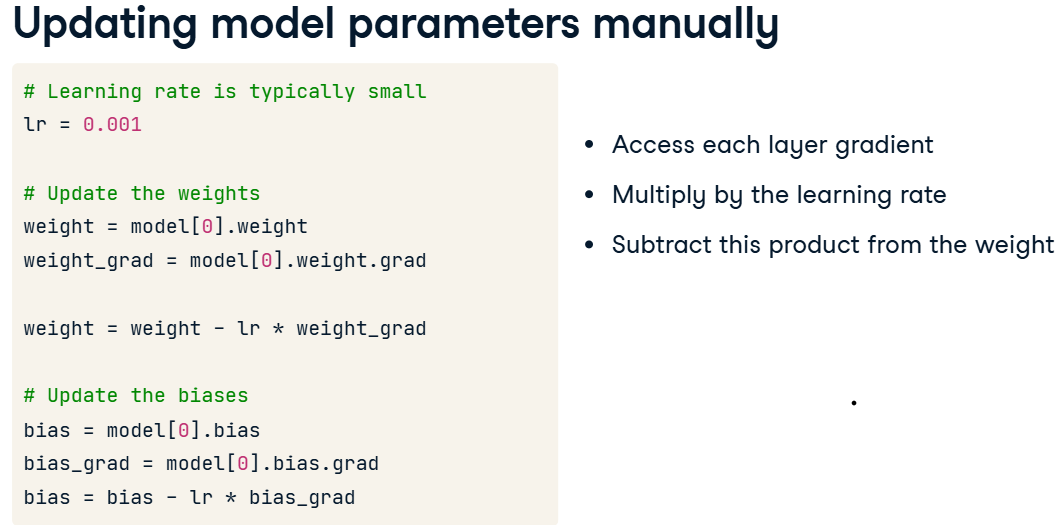

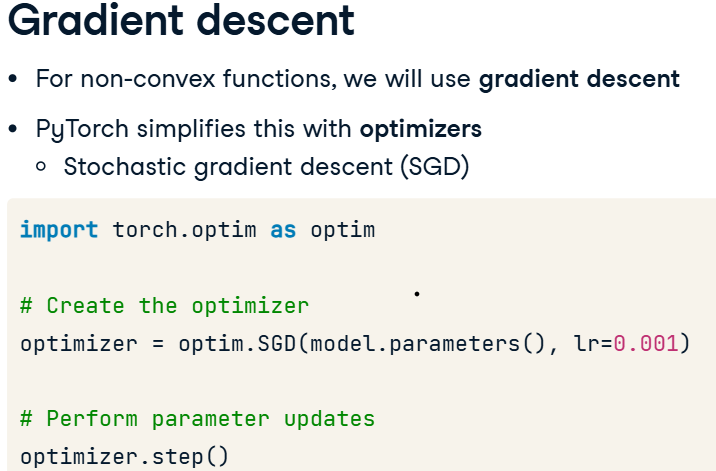

# Part 3: Training a Neural Network with Pytorch


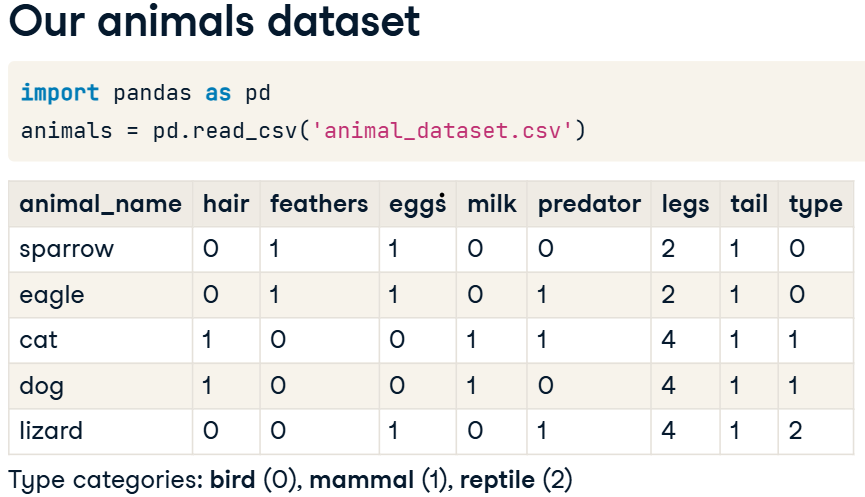

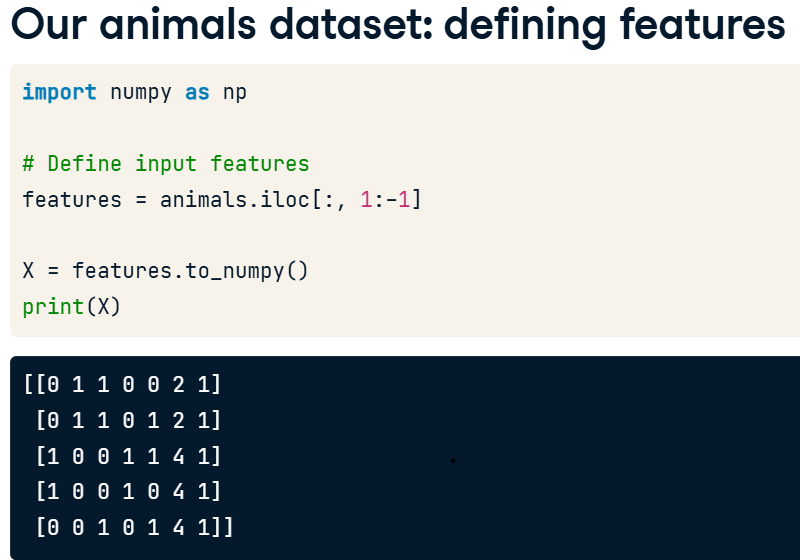

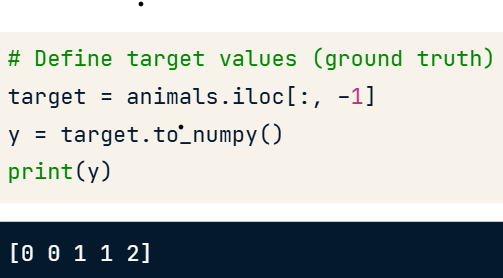

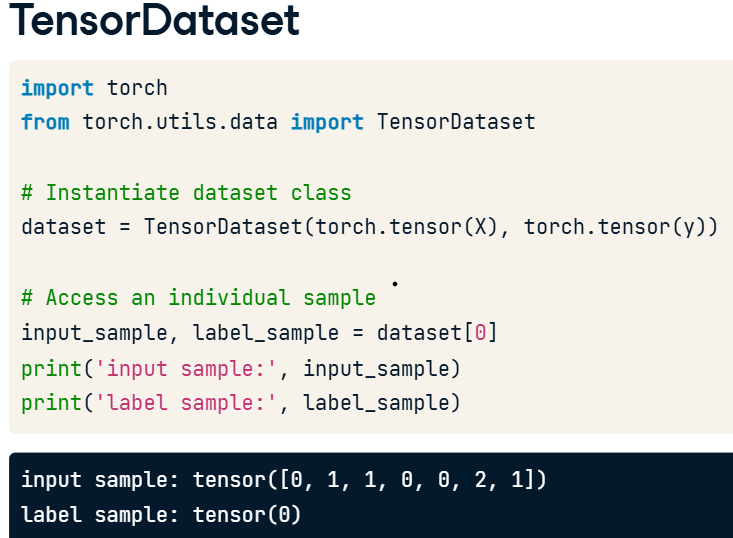

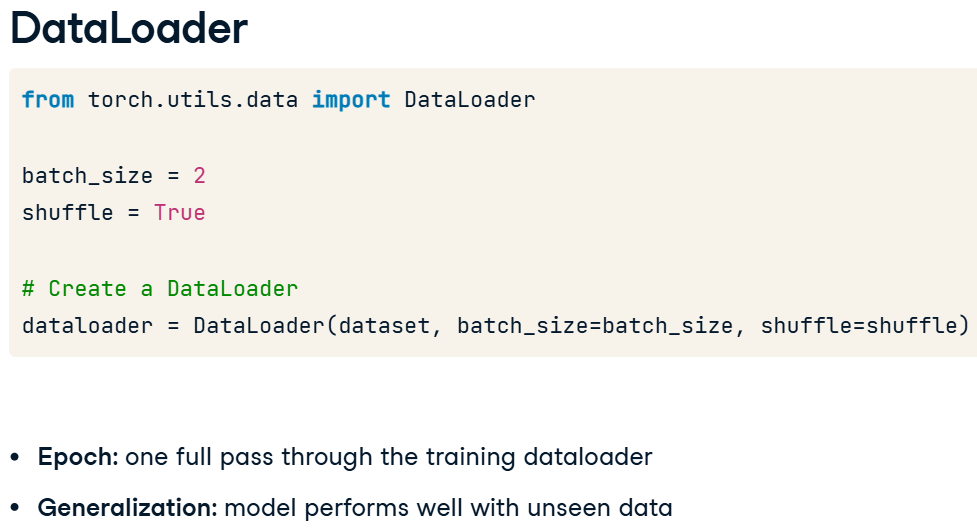

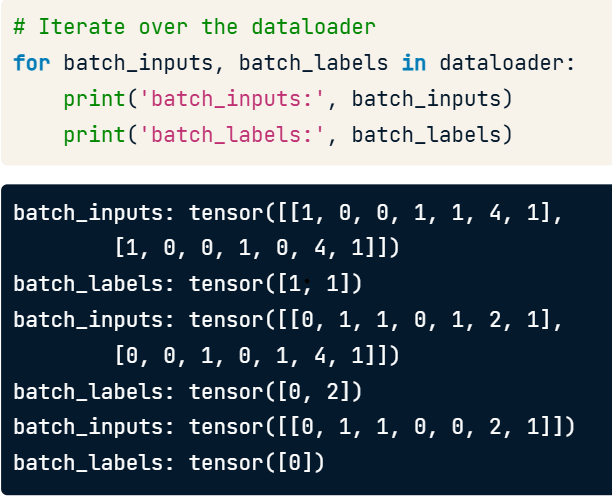

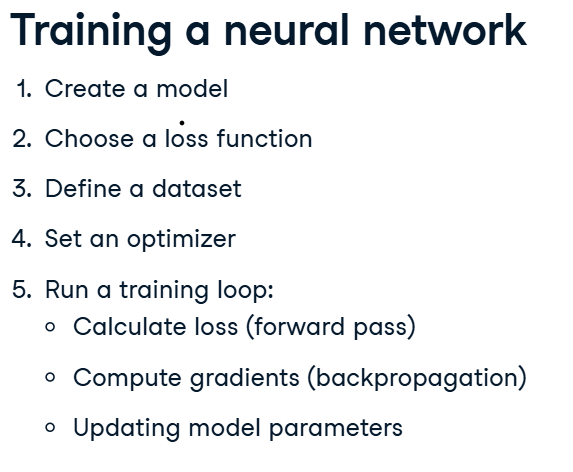

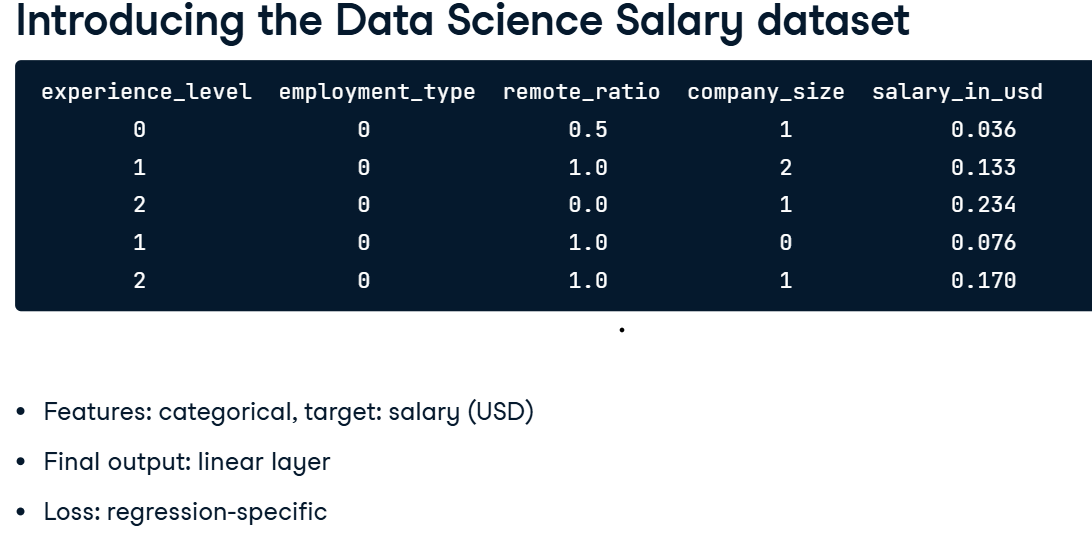

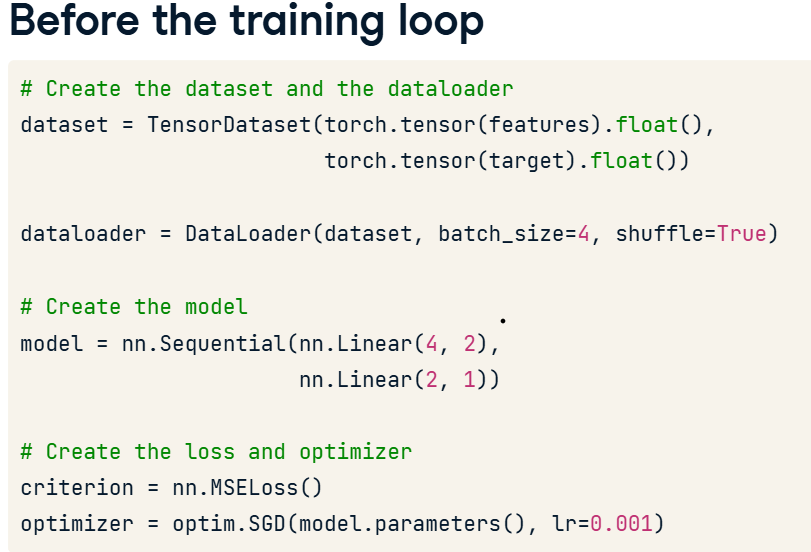

Before the forward pass, we set the gradients to zero using optimizer.zero_grad(), because the optimizer stores gradients from previous steps by default.

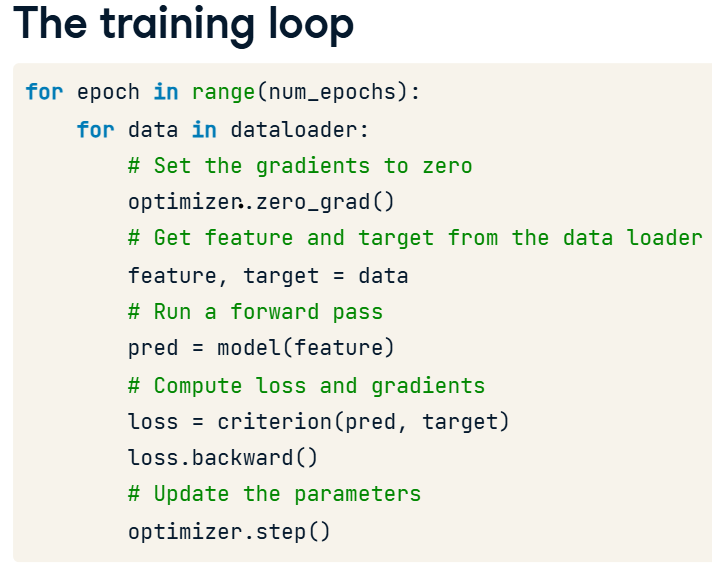

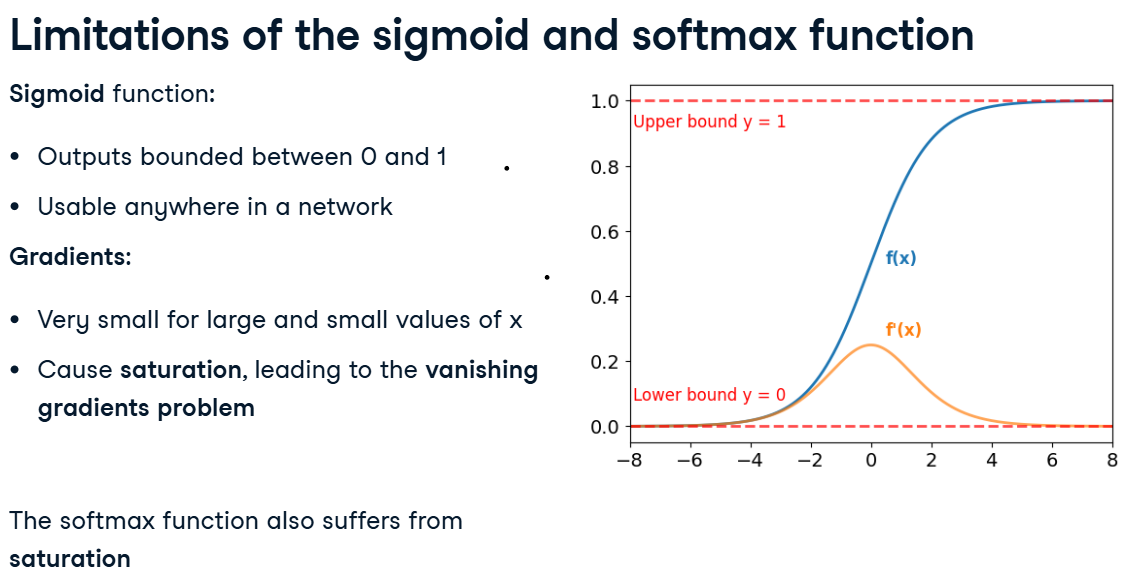

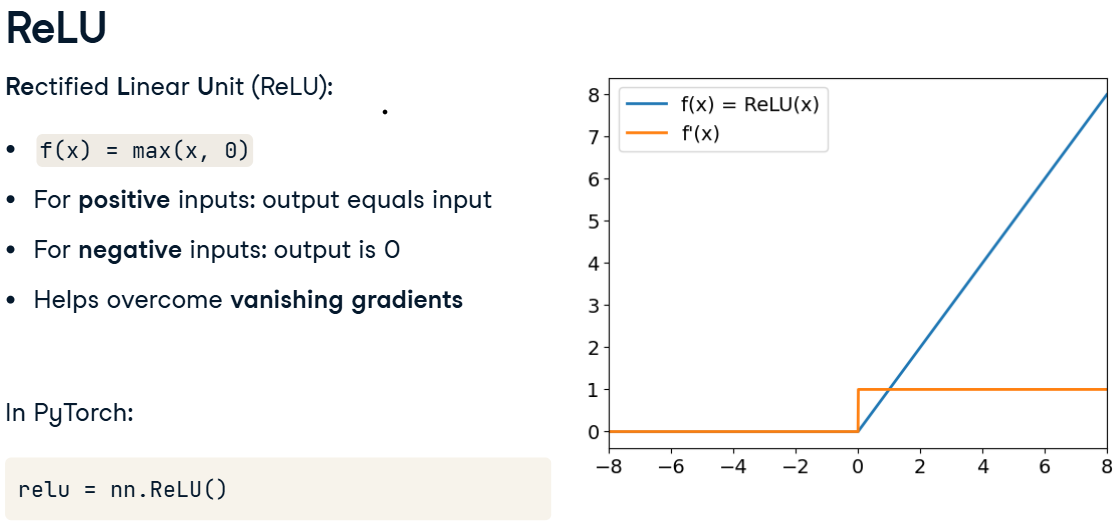

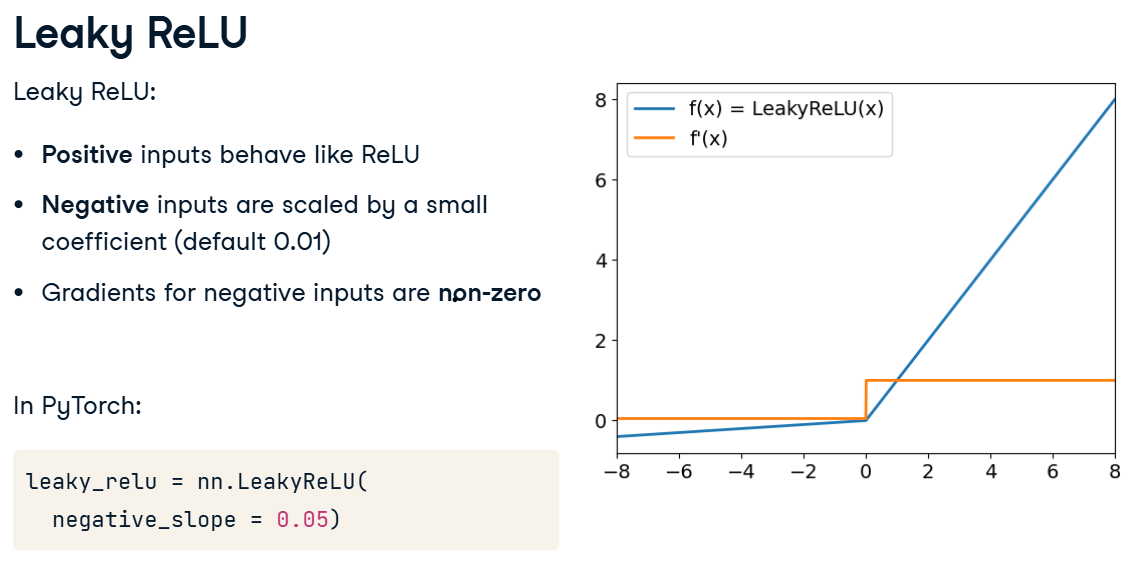

Training a neural network means solving an optimization problem by minimizing the loss function and adjusting model parameters. To do this, we use an algorithm called stochastic gradient descent, or SGD, implemented in PyTorch. Recall this is the optimizer we used to find the global minimum of loss functions. The optimizer takes the model's parameters along with two key arguments: Learning rate, which controls the step size of updates. And momentum, which adds inertia to help the optimizer move smoothly and avoid getting stuck. Understanding their impact helps us optimize efficiency.

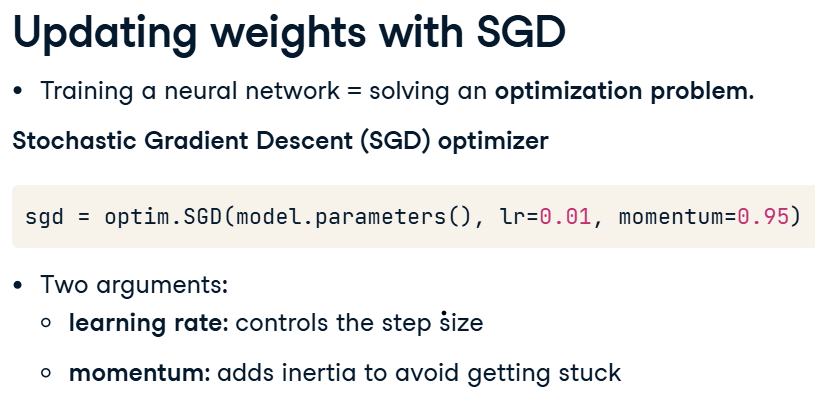

The learning rate and momentum are key hyperparameters in optimization algorithms like gradient descent, which are used to minimize a loss function — ideally finding the global minimum rather than just a local minimum.

### 🎯 1. Learning Rate (α)
Definition: The learning rate determines the step size at each iteration while moving toward a minimum of the loss function.

🔍 Role in Finding Global Minimum:

| Behavior       | Result                                                                                                                 |
| -------------- | ---------------------------------------------------------------------------------------------------------------------- |
| **Too small**  | Very slow convergence, risk of getting stuck in local minima or plateaus                                               |
| **Too large**  | Can overshoot the minimum, diverge, or bounce chaotically without settling                                             |
| **Well-tuned** | Efficient convergence, with enough flexibility to escape shallow local minima and potentially reach the global minimum |

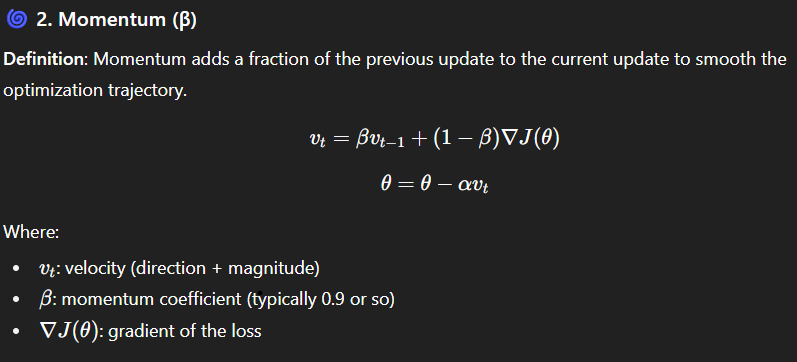

| Behavior                      | Result                                                                    |
| ----------------------------- | ------------------------------------------------------------------------- |
| **No momentum (β = 0)**       | Slower convergence, more zig-zagging                                      |
| **Proper momentum**           | Helps move through small local minima or flat areas, reduces oscillations |
| **Too much momentum (β → 1)** | Risk of overshooting or instability                                       |




# Part 3: Evaluating and Improving models

### Layer initialization
Data normalization scales input features for stability; similarly, the weights of a linear layer are also initialized to small values. This is known as layer initialization. Let's create a small linear layer and check its weight range. We observe that the weights are between -0.125 and +0.125. Why is this important? The output of a neuron in a linear layer is a weighted sum of inputs from the previous layer. Keeping both the input data and layer weights small ensures stable outputs, preventing extreme values that could slow training. Layers can be initialized in different ways and it remains an active area of research.

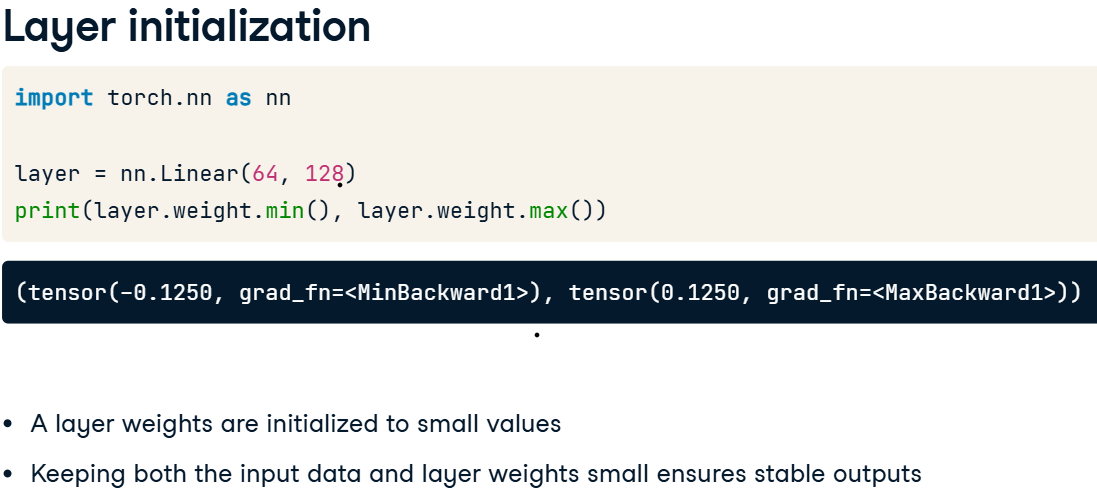

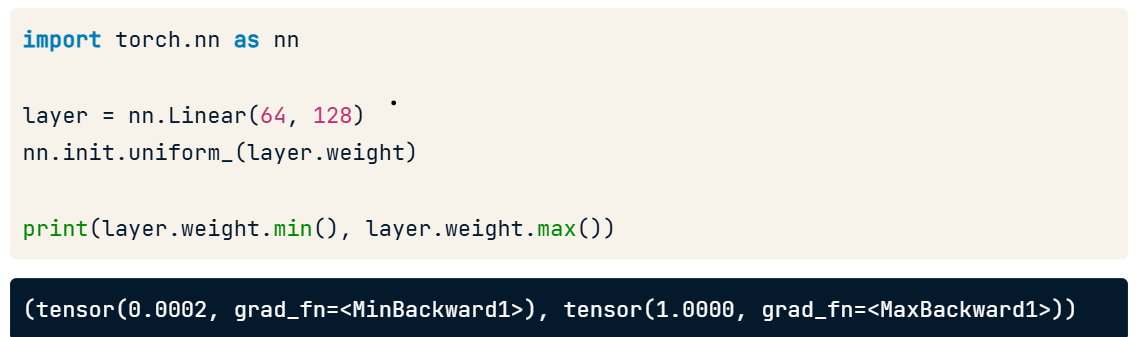

### Transfer learning
In practice, engineers are rarely training a model from randomly initialized weights. Instead they rely on a concept called transfer learning. Transfer learning takes a model that was trained on a first task and reuses it for a second task. For example, we trained a model on US data scientist salaries. We now have new data of salaries in Europe. Instead of training a model using randomly initialized weights, we can load the weights from the first model and use them as a starting point to train on this new dataset. Saving and loading weights can be done using the torch.save and the torch.load functions. These functions work on any type of PyTorch objects.

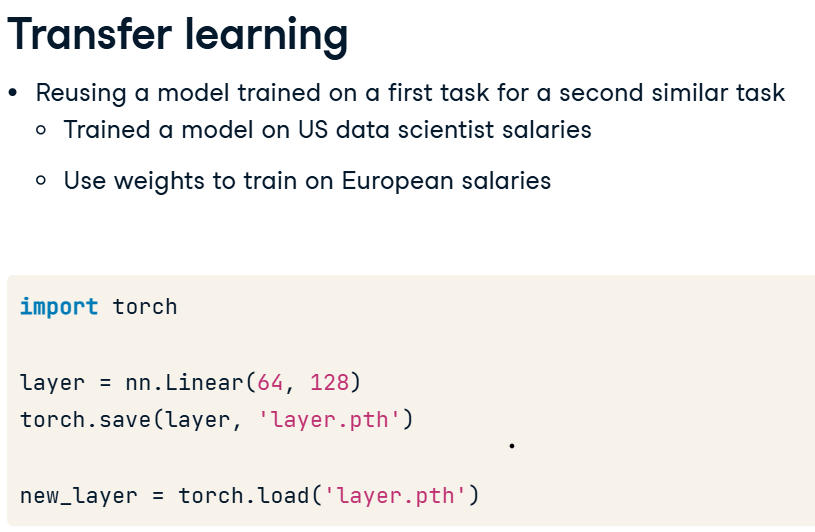

### Fine-tuning
Sometimes, the second task is similar to the first task and we want to perform a specific type of transfer learning, called fine-tuning. In this case, we load weights from a previously trained model, but train the model with a smaller learning rate. We can even train part of a network, if we decide some of the network layers do not need to be trained and choose to freeze them. A rule of thumb is to freeze early layers of the network and fine-tune layers closer to the output layer. This can be achieved by setting each parameter's requires_grad attribute to False. Here, we use the model's named_parameters() method, which returns the name and the parameter itself. We set requires_grad of the first layer's weight to False.

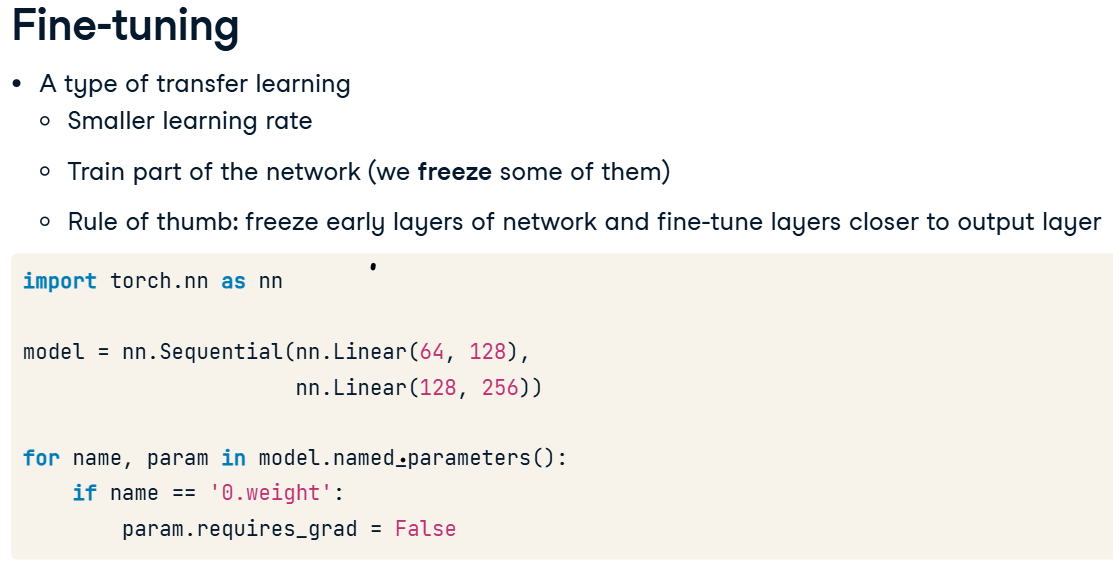

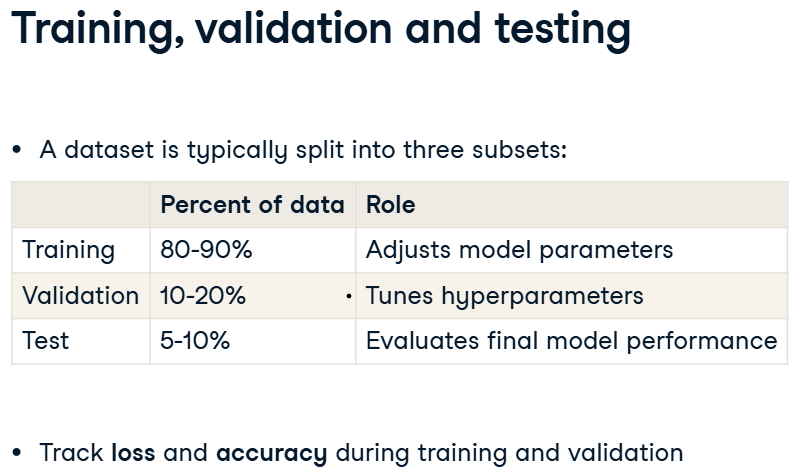

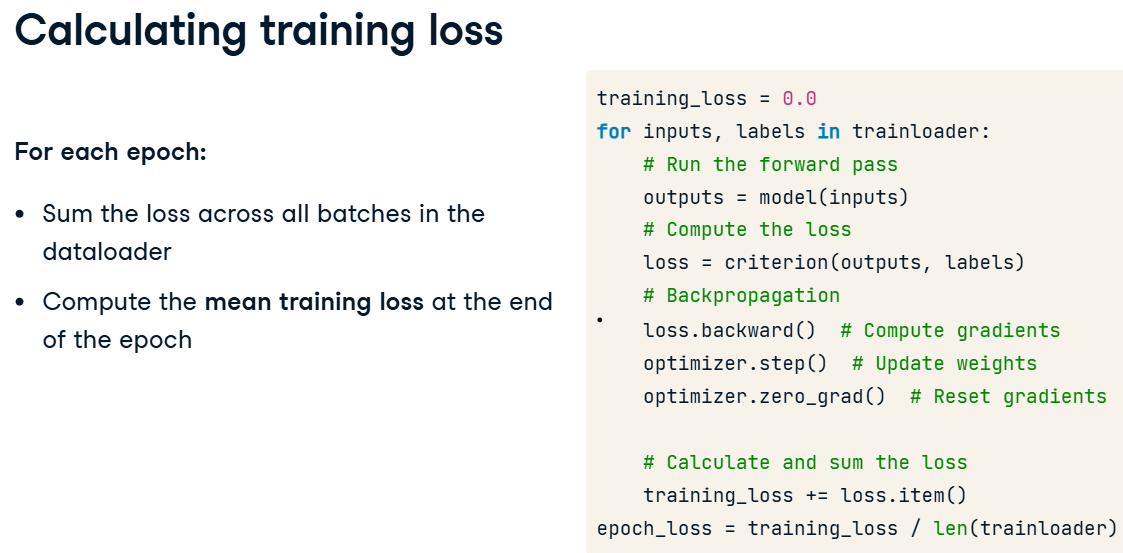

### Calculating validation loss
After each training epoch, we run a validation loop. First, we set the model to evaluation mode using .eval(), as some layers behave differently during training and validation. To improve efficiency, we use torch.no_grad(), which disables gradient calculations since we don't update weights during validation.

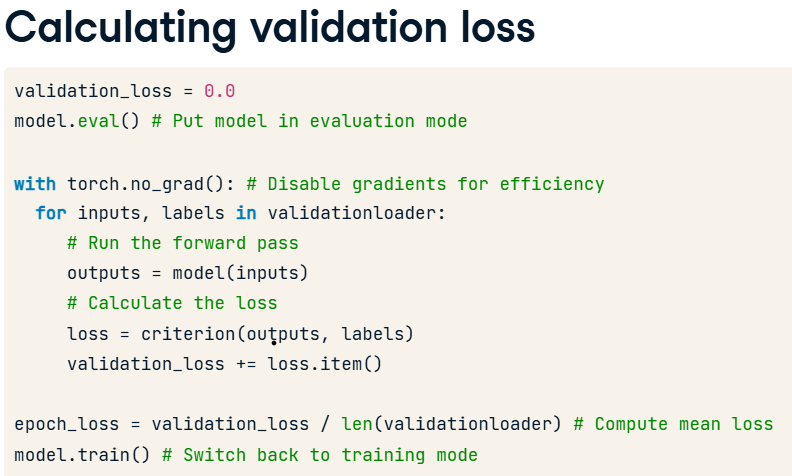

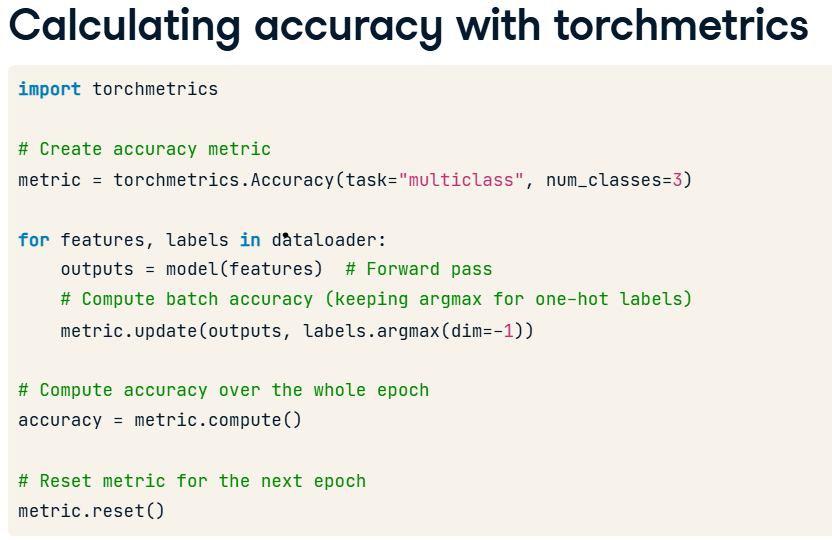

### Overfitting
The model learns the training data too well, including its noise and random fluctuations, resulting in poor performance on new data.

### 📉 Behavior:
Very low training loss

High validation/test loss

### 📈 Cause:
Model is too complex (too many parameters)

Too many epochs (trained too long)

Not enough training data

Lack of regularization

### 🔧 Solutions:
Use a simpler model

Regularization (L1, L2)

Dropout (in neural nets)

Early stopping

More training data

Data augmentation

### Underfitting
The model is too simple to capture the underlying patterns in the data, so it performs poorly on both training and test sets.

### 📉 Behavior:
High training loss

High validation/test loss

### 📈 Cause:
Model is too basic

Trained for too few epochs

Inadequate features or poor feature engineering

### 🔧 Solutions:
Use a more complex model

Train longer (more epochs)

Improve feature engineering

Reduce regularization if it's too strong



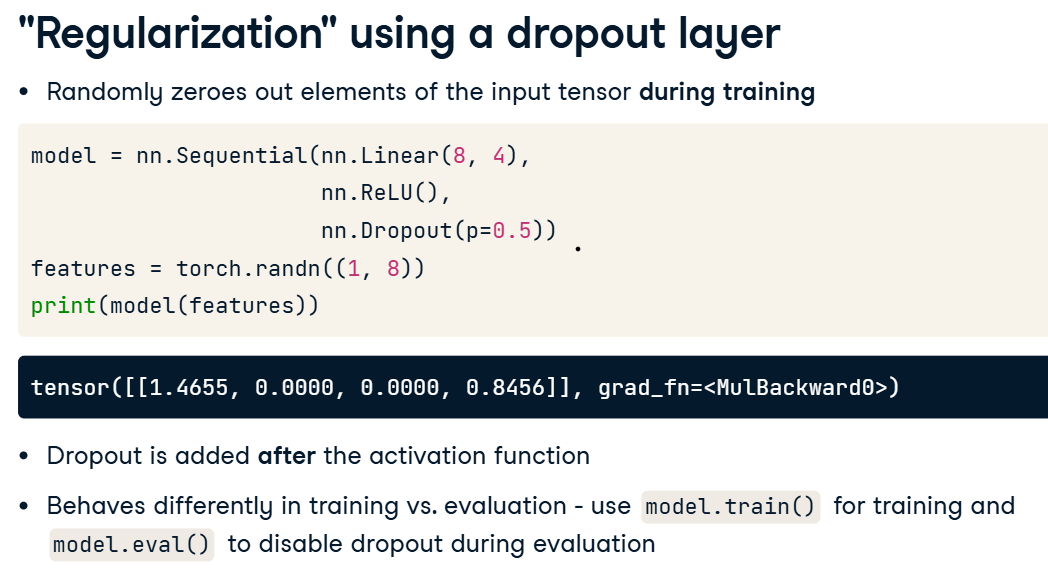

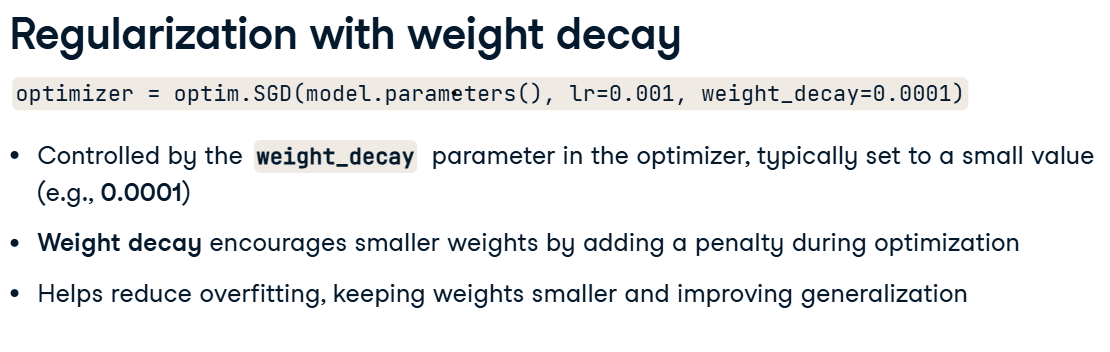

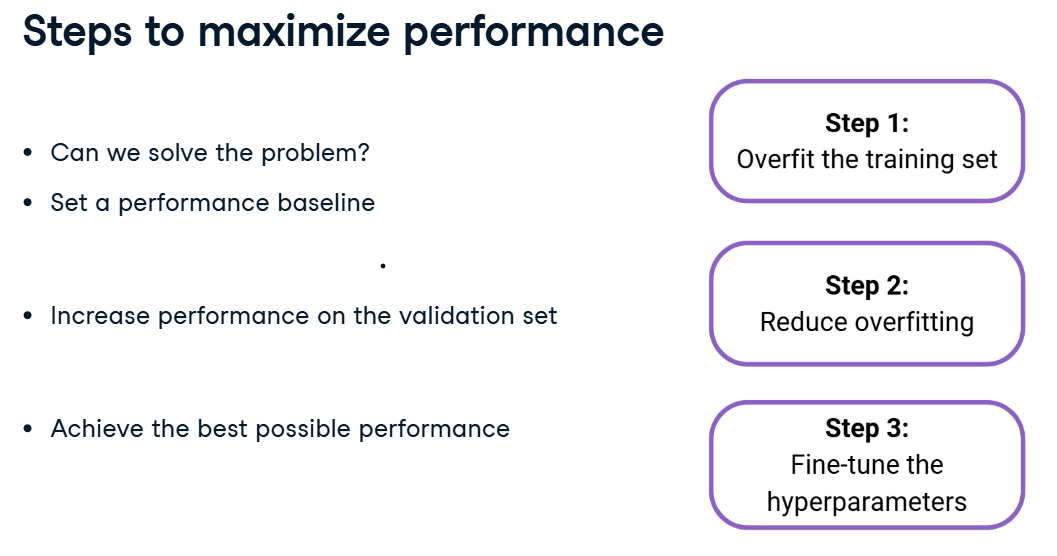

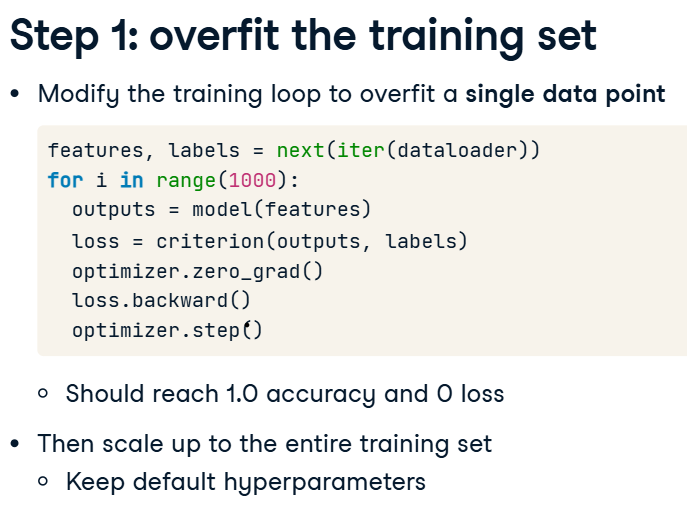

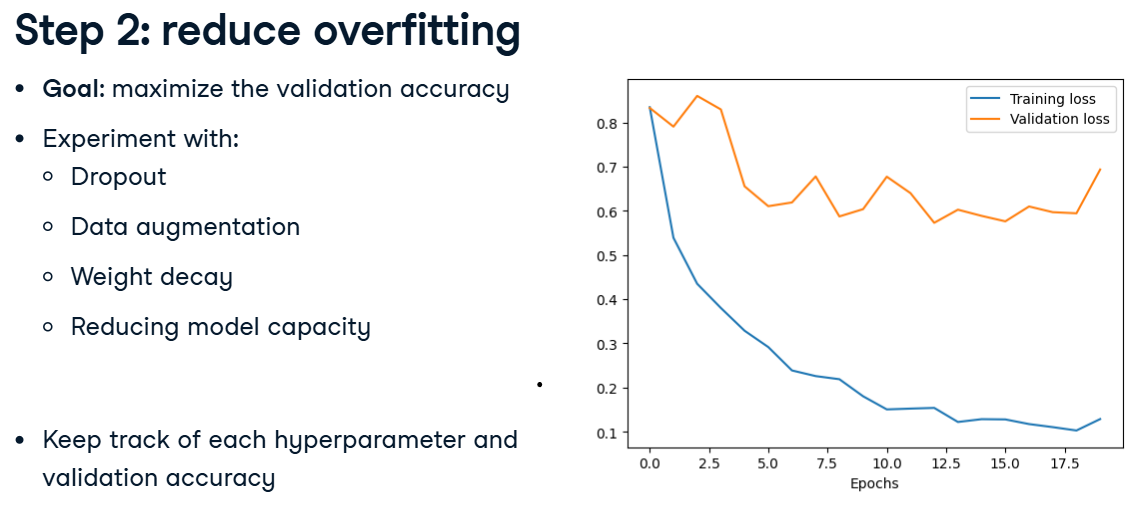

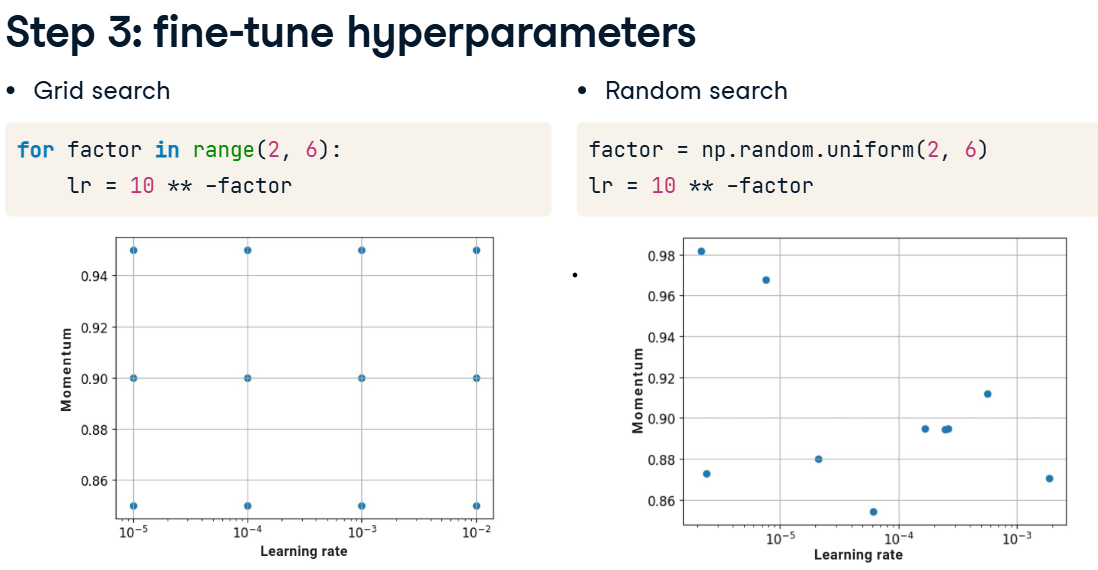